In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

import os
from PIL import Image

import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


from tensorflow import keras
from tensorflow.keras import layers, activations, losses, optimizers, callbacks

I0000 00:00:1781278107.077307  116346 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781278107.149097  116346 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781278108.381428  116346 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
os.listdir()

['asl_dataset',
 'asl_eff0_model.keras',
 'assignment_hint.ipynb',
 'Butterfly',
 'memotion_dataset_7k',
 'model.png',
 'session1.ipynb',
 'session2.ipynb',
 'session3.1.ipynb',
 'session3.ipynb']

In [3]:
df = pd.read_csv(r'memotion_dataset_7k/labels.csv')

In [4]:
df.head()

,image_name,text_ocr,text_corrected,humour,sarcasm,offensive,motivational,overall_sentiment
0,image_1.jpg,LOOK THERE MY FRIEND LIGHTYEAR NOW ALL SOHALIK...,LOOK THERE MY FRIEND LIGHTYEAR NOW ALL SOHALIK...,hilarious,general,not_offensive,not_motivational,very_positive
1,image_2.jpeg,The best of #10 YearChallenge! Completed in le...,The best of #10 YearChallenge! Completed in le...,not_funny,general,not_offensive,motivational,very_positive
2,image_3.JPG,Sam Thorne @Strippin ( Follow Follow Saw every...,Sam Thorne @Strippin ( Follow Follow Saw every...,very_funny,not_sarcastic,not_offensive,not_motivational,positive
3,image_4.png,10 Year Challenge - Sweet Dee Edition,10 Year Challenge - Sweet Dee Edition,very_funny,twisted_meaning,very_offensive,motivational,positive
4,image_5.png,10 YEAR CHALLENGE WITH NO FILTER 47 Hilarious ...,10 YEAR CHALLENGE WITH NO FILTER 47 Hilarious ...,hilarious,very_twisted,very_offensive,not_motivational,neutral


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6979 entries, 0 to 6978
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   image_name         6979 non-null   object
 1   text_ocr           6818 non-null   object
 2   text_corrected     6974 non-null   object
 3   humour             6979 non-null   object
 4   sarcasm            6979 non-null   object
 5   offensive          6979 non-null   object
 6   motivational       6979 non-null   object
 7   overall_sentiment  6979 non-null   object
dtypes: object(8)
memory usage: 436.3+ KB


In [6]:
df.isnull().sum()

image_name             0
text_ocr             161
text_corrected         5
humour                 0
sarcasm                0
offensive              0
motivational           0
overall_sentiment      0
dtype: int64

In [7]:
df = df.drop(columns='text_ocr')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6979 entries, 0 to 6978
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   image_name         6979 non-null   object
 1   text_corrected     6974 non-null   object
 2   humour             6979 non-null   object
 3   sarcasm            6979 non-null   object
 4   offensive          6979 non-null   object
 5   motivational       6979 non-null   object
 6   overall_sentiment  6979 non-null   object
dtypes: object(7)
memory usage: 381.8+ KB


In [9]:
df = df.dropna()

In [10]:
df = df.iloc[:1500]

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 0 to 1500
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   image_name         1500 non-null   object
 1   text_corrected     1500 non-null   object
 2   humour             1500 non-null   object
 3   sarcasm            1500 non-null   object
 4   offensive          1500 non-null   object
 5   motivational       1500 non-null   object
 6   overall_sentiment  1500 non-null   object
dtypes: object(7)
memory usage: 93.8+ KB


In [12]:
df['overall_sentiment'].drop_duplicates()

0     very_positive
2          positive
4           neutral
5          negative
14    very_negative
Name: overall_sentiment, dtype: object

In [13]:
y = df['overall_sentiment']
le = LabelEncoder()
y = le.fit_transform(y)

In [14]:
len(np.unique(y))

5

In [15]:
df.head(0)

,image_name,text_corrected,humour,sarcasm,offensive,motivational,overall_sentiment


In [16]:
df_tabular = df[['humour','sarcasm','offensive','motivational']]

In [17]:
df_tabular.head()

,humour,sarcasm,offensive,motivational
0,hilarious,general,not_offensive,not_motivational
1,not_funny,general,not_offensive,motivational
2,very_funny,not_sarcastic,not_offensive,not_motivational
3,very_funny,twisted_meaning,very_offensive,motivational
4,hilarious,very_twisted,very_offensive,not_motivational


if we keep sparse_output as default or True, the OHE will generate a scipy sparse matrix as it is more memory efficient but I will make it hard to manuplate later, so we change it to False to have a np.array

In [18]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
array_tabular_encoded = ohe.fit_transform(df_tabular)

In [19]:
df_tabular_encoded = pd.DataFrame(array_tabular_encoded, columns=ohe.get_feature_names_out())
df_tabular_encoded.head()

,humour_funny,humour_hilarious,humour_not_funny,humour_very_funny,sarcasm_general,sarcasm_not_sarcastic,sarcasm_twisted_meaning,sarcasm_very_twisted,offensive_hateful_offensive,offensive_not_offensive,offensive_slight,offensive_very_offensive,motivational_motivational,motivational_not_motivational
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [20]:
df_text = df[['text_corrected']]

In [21]:
type(df_text)

pandas.core.frame.DataFrame

In [22]:
df_text['clean_text'] = [re.sub(r'[^\w\s]', '', x) for x in df_text['text_corrected']]

/tmp/ipykernel_116346/1942313630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_text['clean_text'] = [re.sub(r'[^\w\s]', '', x) for x in df_text['text_corrected']]


In [23]:
df_text

,text_corrected,clean_text
0,LOOK THERE MY FRIEND LIGHTYEAR NOW ALL SOHALIK...,LOOK THERE MY FRIEND LIGHTYEAR NOW ALL SOHALIK...
1,The best of #10 YearChallenge! Completed in le...,The best of 10 YearChallenge Completed in less...
2,Sam Thorne @Strippin ( Follow Follow Saw every...,Sam Thorne Strippin Follow Follow Saw everyon...
3,10 Year Challenge - Sweet Dee Edition,10 Year Challenge Sweet Dee Edition
4,10 YEAR CHALLENGE WITH NO FILTER 47 Hilarious ...,10 YEAR CHALLENGE WITH NO FILTER 47 Hilarious ...
...,...,...
1496,I DON'T HAVE A GIRLFRIEND BUT I DO KNOW A WOMA...,I DONT HAVE A GIRLFRIEND BUT I DO KNOW A WOMAN...
1497,MY GIRLFRIEND WANTED A IM MAD AT YOU AND I'M G...,MY GIRLFRIEND WANTED A IM MAD AT YOU AND IM GO...
1498,WHEN SHE KNOWS YOU VE BOUGHT THE RING BUT YOU ...,WHEN SHE KNOWS YOU VE BOUGHT THE RING BUT YOU ...
1499,MY BOYFRIEND SAID HE WAS GOING TO GNE ME SOME ...,MY BOYFRIEND SAID HE WAS GOING TO GNE ME SOME ...


In [24]:
tk = Tokenizer()
tk.fit_on_texts(df_text['clean_text'])
len(tk.word_index)

4942

In [25]:
tk = Tokenizer(num_words=2500)
tk.fit_on_texts(df_text['clean_text'])
text_seq = tk.texts_to_sequences(df_text['clean_text'])

- padding: 1. 'post' ----> embedding + LSTM 
-          2. 'pre' ----> transformers

In [26]:
max_len = 0
for max in text_seq:
    if len(max) > max_len:
        max_len = len(max)

In [27]:
max_len

75

In [28]:
text_seq_pad = pad_sequences(text_seq, padding='post', maxlen=max_len)

In [29]:
text_seq_pad

array([[  84,  115,   14, ...,    0,    0,    0],
       [   1,   47,    9, ...,    0,    0,    0],
       [1866, 1867, 1868, ...,    0,    0,    0],
       ...,
       [  10,  113,  147, ...,    0,    0,    0],
       [  14,  236,  214, ...,    0,    0,    0],
       [  43,    2,   84, ...,    0,    0,    0]],
      shape=(1500, 75), dtype=int32)

In [30]:
df_text_tk_pad = pd.DataFrame(text_seq_pad)

In [31]:
len(df['image_name'])

1500

In [32]:
images = []
image_dir = r'memotion_dataset_7k/images'
image_size = (256,256)

# for file in sorted(os.listdir(image_dir), key= lambda x: int(x.split('_')[1].split('.')[0])): wrong
for file in sorted(df['image_name'], key= lambda x: int(x.split('_')[1].split('.')[0])):
    file_path = os.path.join(image_dir, file)
    img = Image.open(file_path)

    img = img.convert('RGB')
    img = img.resize(image_size)
    img_arr = np.array(img)/255

    images.append(img_arr)

len(images)

1500

In [33]:
images = np.array(images)

Text(0.5, 1.0, 'To Be Continued BABY GODFATHER CHALLANGE GONE WRONG SGOTBEATEN BY MAFIA An interesting Squid')

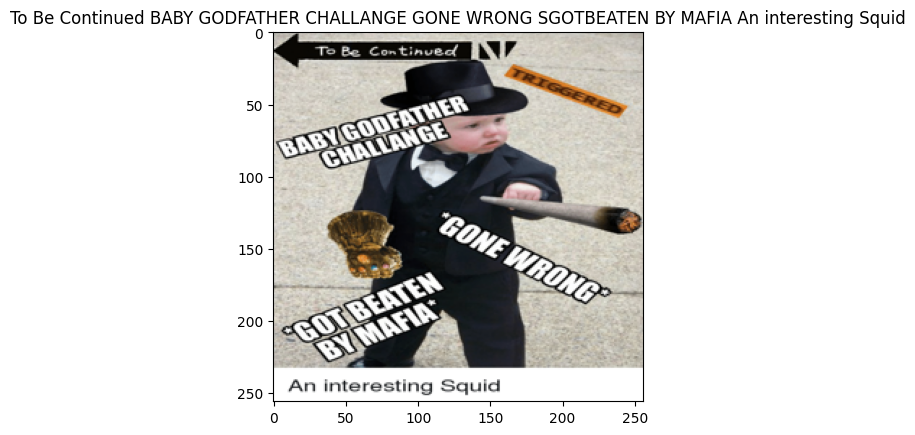

In [34]:
i = np.random.randint(0,1500)
plt.imshow(images[i])
plt.title(df_text['clean_text'].iloc[i])

In [35]:
df_tabular_encoded.shape

(1500, 14)

In [36]:
df_text_tk_pad.shape

(1500, 75)

In [37]:
images.shape

(1500, 256, 256, 3)

In [38]:
y.shape

(1500,)

In [39]:
1500 * 0.8

1200.0

In [40]:
a = np.random.permutation(5)
a

array([3, 4, 0, 2, 1])

In [41]:
n_samples = len(df_tabular_encoded)
shuffle_indices = np.random.permutation(n_samples)

df_tabular_encoded_suffled = df_tabular_encoded.iloc[shuffle_indices]
df_text_tk_pad_suffled = df_text_tk_pad.iloc[shuffle_indices]
images_shuffled = images[shuffle_indices]
y_shuffled = y[shuffle_indices]

df_tabular_encoded_train = df_tabular_encoded_suffled[:1200]
df_tabular_encoded_test = df_tabular_encoded_suffled[1200:]

df_text_tk_pad_train  = df_text_tk_pad_suffled[:1200]
df_text_tk_pad_test  = df_text_tk_pad_suffled[1200:]

images_train  = images_shuffled[:1200]
images_test  = images_shuffled[1200:]

y_train  = y_shuffled[:1200]
y_test   = y_shuffled[1200:]

In [42]:
y_test.shape
images

array([[[[0.50196078, 0.38431373, 0.37647059],
         [0.50196078, 0.38431373, 0.37647059],
         [0.50196078, 0.38431373, 0.37647059],
         ...,
         [0.36862745, 0.38823529, 0.39607843],
         [0.36078431, 0.38039216, 0.39215686],
         [0.34509804, 0.37647059, 0.38431373]],

        [[0.50588235, 0.38823529, 0.38039216],
         [0.50588235, 0.38823529, 0.38039216],
         [0.50588235, 0.38823529, 0.38039216],
         ...,
         [0.36862745, 0.38823529, 0.39607843],
         [0.36078431, 0.38039216, 0.39215686],
         [0.34509804, 0.37647059, 0.38431373]],

        [[0.50588235, 0.38823529, 0.38039216],
         [0.50588235, 0.38823529, 0.38039216],
         [0.50588235, 0.38823529, 0.38039216],
         ...,
         [0.36862745, 0.38823529, 0.39607843],
         [0.36078431, 0.38039216, 0.39215686],
         [0.34509804, 0.37647059, 0.38431373]],

        ...,

        [[0.47843137, 0.26666667, 0.15686275],
         [0.56862745, 0.5254902 , 0.4745098 ]

In [43]:
# ====================== Image branch =================================

image_input = layers.Input(shape=(256,256,3), name= 'image')
cnn1  = layers.Conv2D(64, 3, activation='relu', padding='same')(image_input)
bn1   = layers.BatchNormalization()(cnn1)
drop1 = layers.Dropout(0.2)(bn1)
max1  = layers.MaxPool2D((2,2))(drop1)

cnn2  = layers.Conv2D(64, 3, activation='relu', padding='same')(max1)
bn2   = layers.BatchNormalization()(cnn2)
drop2 = layers.Dropout(0.2)(bn2)
max2  = layers.MaxPool2D((2,2))(drop2)

gap   = layers.GlobalAveragePooling2D()(max2)

fc1   = layers.Dense(64, activation='relu')(gap)


# ======================== Text branch ====================================

text_input = layers.Input(shape=(75,), name = 'text')
emb1       = layers.Embedding(input_dim= 2500, output_dim= 16, input_length= 75)(text_input)
bilstm     = layers.Bidirectional(layers.LSTM(64, dropout=0.2, return_sequences=True))(emb1)
gru1       = layers.GRU(32)(bilstm)

fc2        = layers.Dense(64, activation='relu')(gru1) 

# ====================== Tabular branch ================================

tabular_input = keras.Input(shape=(14,), name = 'tabular')
fc3 = layers.Dense(32, activation='relu')(tabular_input)
drop3 = layers.Dropout(0.3)(fc3)
fc4   = layers.Dense(16, activation='relu')(drop3)
drop4 = layers.Dropout(0.2)(fc4)

# =================== fusion ==================
concat1 = layers.Concatenate()([fc1, fc2, drop4])

fc5   = layers.Dense(128, activation='relu')(concat1)
fc_act = layers.PReLU()(fc5)

output = layers.Dense(5, activation='softmax')(fc_act)

model = keras.Model(inputs = [image_input, text_input, tabular_input], outputs = output)

adam = optimizers.Adam(learning_rate=0.002)

model.compile(
    optimizer = adam,
    loss = losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)
model.summary()

W0000 00:00:1781278119.851529  116346 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1781278119.860169  116346 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1781278119.994574  116346 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2158 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
/home/milad/.virtualenvs/notebook/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ image[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text (InputLayer)   │ (None, 75)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular             │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 75, 16)    │     40,000 │ text[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │        480 │ tabular[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ dropout_1[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 75, 128)   │     41,472 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling2d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │     15,552 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        528 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 162,869 (636.21 KB)

 Trainable params: 162,613 (635.21 KB)

 Non-trainable params: 256 (1.00 KB)

In [44]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5)

history = model.fit(

    {
        'image': images_train,
        'text': df_text_tk_pad_train,
        'tabular': df_tabular_encoded_train,
    },

    y_train,
    validation_split = 0.2,
    epochs = 50,
    batch_size = 8,
    callbacks = [es, rlr]
)

Epoch 1/50


E0000 00:00:1781278123.879945  116346 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1781278124.808933  116466 cuda_dnn.cc:461] Loaded cuDNN version 92200
W0000 00:00:1781278125.994615  116466 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.28GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


  1/120 ━━━━━━━━━━━━━━━━━━━━ 12:38 6s/step - accuracy: 0.5000 - loss: 1.4721

W0000 00:00:1781278127.703087  116466 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.12GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


120/120 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.4219 - loss: 1.3142 - val_accuracy: 0.2875 - val_loss: 1.4017 - learning_rate: 0.0020
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.4250 - loss: 1.2796 - val_accuracy: 0.3875 - val_loss: 1.3220 - learning_rate: 0.0020
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.4510 - loss: 1.2567 - val_accuracy: 0.4042 - val_loss: 1.3780 - learning_rate: 0.0020
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.4604 - loss: 1.2409 - val_accuracy: 0.3625 - val_loss: 1.4754 - learning_rate: 0.0020
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.4615 - loss: 1.2331 - val_accuracy: 0.4167 - val_loss: 1.4062 - learning_rate: 0.0020
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.4771 - loss: 1.2305 - val_accuracy: 0.4333 - val_loss: 1.3127 - learning_rate: 0.0020
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.4844 - loss: 1.2228 - val

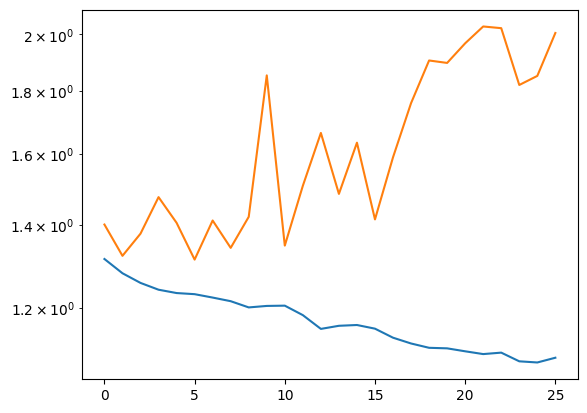

In [45]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.yscale('log')

In [ ]:
y_pred = model.predict(    {
        'image': images_test,
        'text': df_text_tk_pad_test,
        'tabular': df_tabular_encoded_test,
    },)

accuracy_score(y_test, np.argmax(y_pred, axis=1))

W0000 00:00:1781278424.059841  116467 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 528.00MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1781278424.059865  116467 gpu_utils.cc:69] Failed to allocate memory for convolution redzone checking; skipping this check. This is benign and only means that we won't check cudnn for out-of-bounds reads and writes. This message will only be printed once.
W0000 00:00:1781278424.078801  116467 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 552.01MiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1781278424.078836  116467 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 552.01MiB with freed_by_count=0. The 

 5/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

W0000 00:00:1781278424.375283  116467 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.04GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step


W0000 00:00:1781278425.129383  116450 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.41GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


0.41333333333333333